# Porównanie architektur CNN z transfer learningiem w zadaniu klasyfikacji obrazów

Autor: Kamil Klepusewicz  
Przedmiot: Projektowanie i Zastosowania Sieci Neuronowych

## Cel projektu

Celem projektu jest porównanie skuteczności wybranych architektur konwolucyjnych sieci neuronowych w zadaniu klasyfikacji obrazów. W projekcie porównano prostą sieć CNN trenowaną od zera z modelami pretrenowanymi wykorzystującymi transfer learning. Modele oceniono na zbiorze CIFAR-10 pod względem dokładności klasyfikacji, czasu treningu oraz liczby parametrów.

## Zakres projektu

W ramach projektu wykorzystano:
- prostą sieć CNN trenowaną od zera,
- model ResNet18 z transfer learningiem,
- model MobileNetV2 z transfer learningiem.

Modele zostały porównane na podstawie:
- dokładności klasyfikacji,
- wartości funkcji straty,
- czasu treningu,
- liczby parametrów,
- przykładowych predykcji oraz macierzy pomyłek.

## Opis problemu

Klasyfikacja obrazów jest jednym z podstawowych zastosowań konwolucyjnych sieci neuronowych. Celem zadania jest przypisanie obrazu do jednej z ustalonych klas na podstawie jego zawartości wizualnej.

W projekcie wykorzystano zbiór CIFAR-10, który zawiera obrazy należące do 10 klas: airplane, automobile, bird, cat, deer, dog, frog, horse, ship oraz truck. Obrazy w oryginalnym zbiorze mają rozmiar 32x32 piksele, jednak na potrzeby modeli pretrenowanych zostały przeskalowane do rozmiaru 224x224 piksele.

## Przygotowanie środowiska i danych

Do realizacji projektu wykorzystano język Python oraz bibliotekę PyTorch. Obliczenia wykonano z użyciem GPU dostępnego w środowisku Kaggle.

Dane zostały pobrane automatycznie z biblioteki torchvision. Ze względu na ograniczony czas obliczeń wykorzystano podzbiór danych: 10000 obrazów treningowych oraz 2000 obrazów testowych. Pozwala to szybko porównać modele, zachowując jednocześnie sensowną reprezentację problemu.

In [2]:
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 64
NUM_CLASSES = 10

TRAIN_SUBSET_SIZE = 10000
TEST_SUBSET_SIZE = 2000

EPOCHS_BASELINE = 5
EPOCHS_TRANSFER = 3

classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_indices = list(range(TRAIN_SUBSET_SIZE))
test_indices = list(range(TEST_SUBSET_SIZE))

train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [54:42<00:00, 51.9kB/s]   


Train samples: 10000
Test samples: 2000


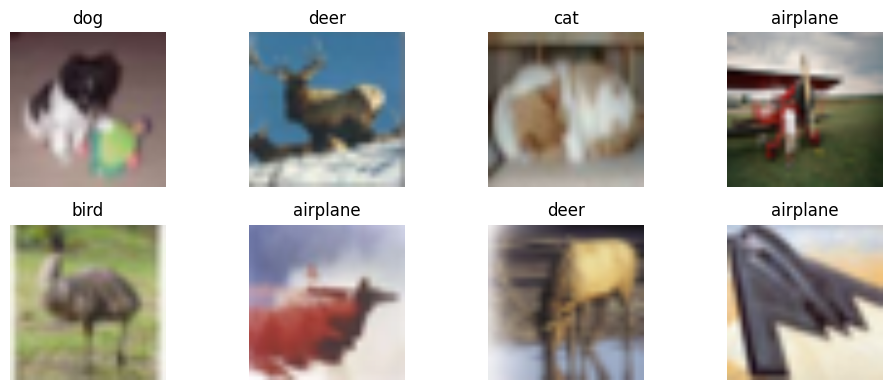

In [5]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()
plt.show()

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, model_name):
    model = model.to(device)
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
            f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}"
        )

    training_time = time.time() - start_time

    return model, history, training_time


def evaluate_model(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

## Model bazowy: prosta sieć CNN trenowana od zera

Pierwszym modelem jest prosta konwolucyjna sieć neuronowa zbudowana od podstaw. Model ten pełni rolę punktu odniesienia dla modeli pretrenowanych.

Sieć składa się z kilku warstw konwolucyjnych, funkcji aktywacji ReLU, warstw MaxPooling oraz klasyfikatora końcowego. Wszystkie parametry tego modelu są uczone od zera na zbiorze CIFAR-10.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


simple_cnn = SimpleCNN(NUM_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn.parameters(), lr=0.001)

simple_cnn, simple_history, simple_time = train_model(
    simple_cnn,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    EPOCHS_BASELINE,
    "Simple CNN"
)

simple_loss, simple_acc = evaluate_model(simple_cnn, test_loader, criterion)

print("Simple CNN final accuracy:", simple_acc)
print("Simple CNN training time:", simple_time)
print("Simple CNN trainable parameters:", count_parameters(simple_cnn))

Simple CNN | Epoch 1/5 | Train loss: 1.8511 | Train acc: 0.3346 | Test loss: 1.5300 | Test acc: 0.4365
Simple CNN | Epoch 2/5 | Train loss: 1.4816 | Train acc: 0.4632 | Test loss: 1.3873 | Test acc: 0.5010
Simple CNN | Epoch 3/5 | Train loss: 1.2941 | Train acc: 0.5376 | Test loss: 1.2663 | Test acc: 0.5435
Simple CNN | Epoch 4/5 | Train loss: 1.1349 | Train acc: 0.5946 | Test loss: 1.2777 | Test acc: 0.5395
Simple CNN | Epoch 5/5 | Train loss: 1.0100 | Train acc: 0.6390 | Test loss: 1.2170 | Test acc: 0.5605
Simple CNN final accuracy: 0.5605
Simple CNN training time: 109.80813765525818
Simple CNN trainable parameters: 25786186


## ResNet18 z wykorzystaniem transfer learningu

Drugim modelem jest ResNet18 pretrenowany na zbiorze ImageNet. W projekcie wykorzystano transfer learning, czyli przeniesienie wiedzy z wcześniej wytrenowanego modelu na nowe zadanie klasyfikacji.

W modelu zamrożono wszystkie wcześniejsze warstwy odpowiedzialne za ekstrakcję cech, a następnie zastąpiono ostatnią warstwę klasyfikacyjną nową warstwą dostosowaną do 10 klas zbioru CIFAR-10. Trenowana była tylko ostatnia warstwa modelu.

In [8]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet18.parameters():
    param.requires_grad = False

num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, NUM_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

resnet18, resnet_history, resnet_time = train_model(
    resnet18,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    EPOCHS_TRANSFER,
    "ResNet18"
)

resnet_loss, resnet_acc = evaluate_model(resnet18, test_loader, criterion)

print("ResNet18 final accuracy:", resnet_acc)
print("ResNet18 training time:", resnet_time)
print("ResNet18 trainable parameters:", count_parameters(resnet18))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s] 


ResNet18 | Epoch 1/3 | Train loss: 1.2832 | Train acc: 0.6042 | Test loss: 0.8732 | Test acc: 0.7270
ResNet18 | Epoch 2/3 | Train loss: 0.7790 | Train acc: 0.7520 | Test loss: 0.7637 | Test acc: 0.7385
ResNet18 | Epoch 3/3 | Train loss: 0.6957 | Train acc: 0.7712 | Test loss: 0.6969 | Test acc: 0.7625
ResNet18 final accuracy: 0.7625
ResNet18 training time: 45.78789019584656
ResNet18 trainable parameters: 5130


## MobileNetV2 z wykorzystaniem transfer learningu

Trzecim modelem jest MobileNetV2, czyli architektura zaprojektowana z myślą o małej liczbie parametrów i szybkim działaniu. Podobnie jak w przypadku ResNet18 wykorzystano model pretrenowany na ImageNet.

W projekcie zamrożono część odpowiedzialną za ekstrakcję cech, a następnie zmodyfikowano klasyfikator końcowy tak, aby zwracał 10 klas. Dzięki temu możliwe było porównanie lekkiej architektury MobileNetV2 z klasyczną architekturą ResNet18.

In [9]:
mobilenet_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

for param in mobilenet_v2.parameters():
    param.requires_grad = False

num_features = mobilenet_v2.classifier[1].in_features
mobilenet_v2.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_v2.classifier[1].parameters(), lr=0.001)

mobilenet_v2, mobilenet_history, mobilenet_time = train_model(
    mobilenet_v2,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    EPOCHS_TRANSFER,
    "MobileNetV2"
)

mobilenet_loss, mobilenet_acc = evaluate_model(mobilenet_v2, test_loader, criterion)

print("MobileNetV2 final accuracy:", mobilenet_acc)
print("MobileNetV2 training time:", mobilenet_time)
print("MobileNetV2 trainable parameters:", count_parameters(mobilenet_v2))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s] 


MobileNetV2 | Epoch 1/3 | Train loss: 1.2102 | Train acc: 0.6114 | Test loss: 0.8552 | Test acc: 0.7145
MobileNetV2 | Epoch 2/3 | Train loss: 0.8248 | Train acc: 0.7215 | Test loss: 0.7527 | Test acc: 0.7390
MobileNetV2 | Epoch 3/3 | Train loss: 0.7600 | Train acc: 0.7360 | Test loss: 0.7258 | Test acc: 0.7445
MobileNetV2 final accuracy: 0.7445
MobileNetV2 training time: 51.07081055641174
MobileNetV2 trainable parameters: 12810


## Porównanie wyników

Modele porównano pod względem dokładności klasyfikacji na zbiorze testowym, czasu treningu oraz liczby trenowanych parametrów. Szczególnie istotna jest liczba trenowanych parametrów, ponieważ w modelach pretrenowanych większość warstw została zamrożona, a trenowany był jedynie klasyfikator końcowy.

In [10]:
results = pd.DataFrame([
    {
        "Model": "Simple CNN",
        "Test accuracy": simple_acc,
        "Training time [s]": simple_time,
        "Trainable parameters": count_parameters(simple_cnn)
    },
    {
        "Model": "ResNet18",
        "Test accuracy": resnet_acc,
        "Training time [s]": resnet_time,
        "Trainable parameters": count_parameters(resnet18)
    },
    {
        "Model": "MobileNetV2",
        "Test accuracy": mobilenet_acc,
        "Training time [s]": mobilenet_time,
        "Trainable parameters": count_parameters(mobilenet_v2)
    }
])

results["Test accuracy [%]"] = results["Test accuracy"] * 100
results

,Model,Test accuracy,Training time [s],Trainable parameters,Test accuracy [%]
0,Simple CNN,0.5605,109.808138,25786186,56.05
1,ResNet18,0.7625,45.787890,5130,76.25
2,MobileNetV2,0.7445,51.070811,12810,74.45


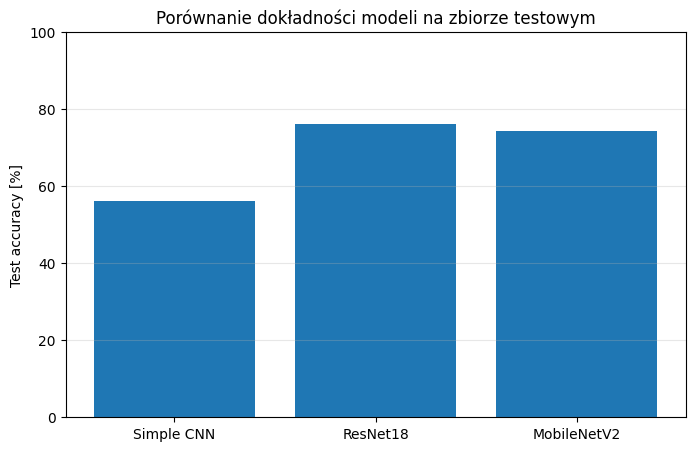

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Test accuracy [%]"])
plt.ylabel("Test accuracy [%]")
plt.title("Porównanie dokładności modeli na zbiorze testowym")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.show()

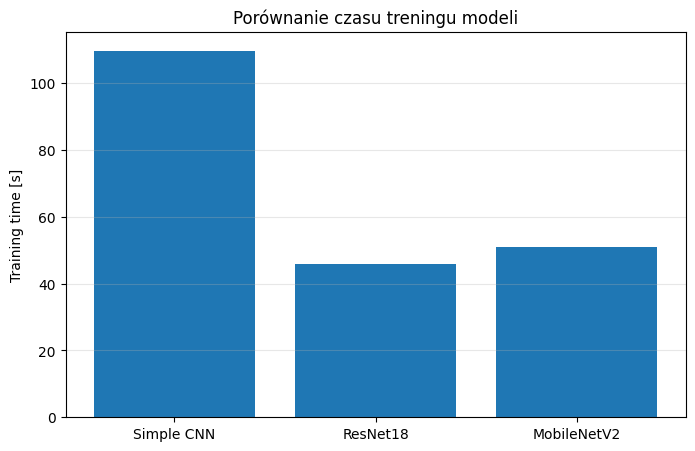

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Training time [s]"])
plt.ylabel("Training time [s]")
plt.title("Porównanie czasu treningu modeli")
plt.grid(axis="y", alpha=0.3)
plt.show()

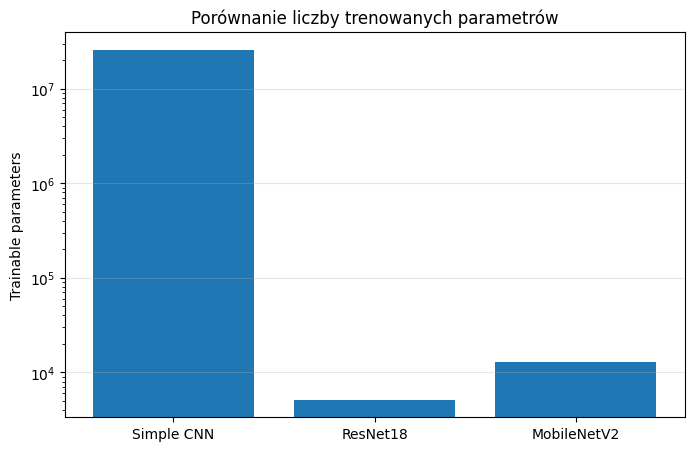

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Trainable parameters"])
plt.ylabel("Trainable parameters")
plt.title("Porównanie liczby trenowanych parametrów")
plt.yscale("log")
plt.grid(axis="y", alpha=0.3)
plt.show()

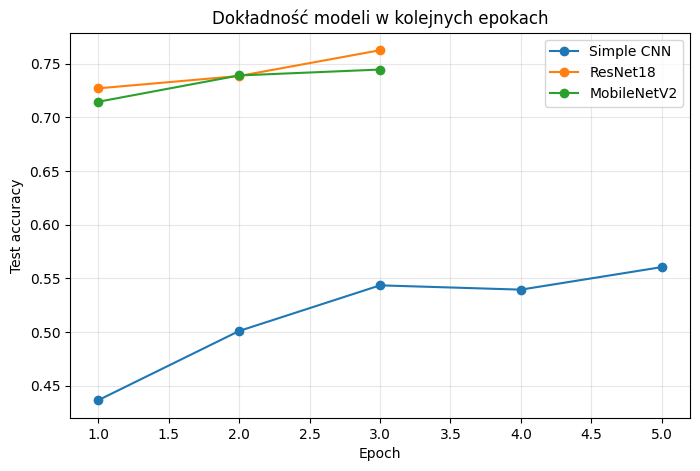

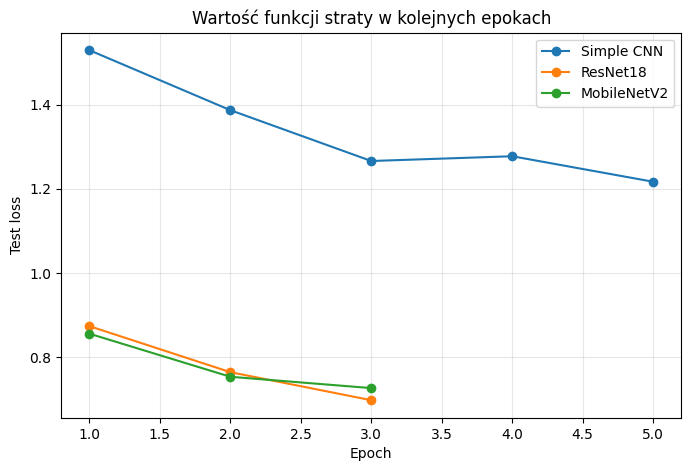

In [14]:
def plot_history(histories, metric, title, ylabel):
    plt.figure(figsize=(8, 5))

    for model_name, history in histories.items():
        epochs = range(1, len(history[metric]) + 1)
        plt.plot(epochs, history[metric], marker="o", label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


histories = {
    "Simple CNN": simple_history,
    "ResNet18": resnet_history,
    "MobileNetV2": mobilenet_history
}

plot_history(histories, "test_acc", "Dokładność modeli w kolejnych epokach", "Test accuracy")
plot_history(histories, "test_loss", "Wartość funkcji straty w kolejnych epokach", "Test loss")

<Figure size 1000x1000 with 0 Axes>

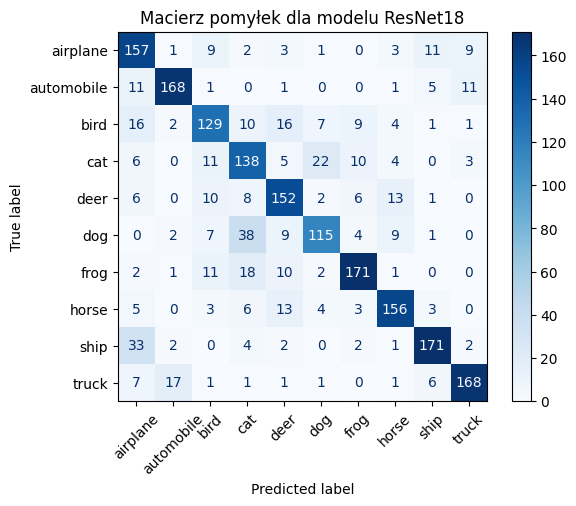

In [15]:
def get_predictions(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(resnet18, test_loader)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Macierz pomyłek dla modelu ResNet18")
plt.show()

## Analiza wyników

Najwyższą dokładność na zbiorze testowym uzyskał model ResNet18. Model ten osiągnął wynik około 76%, przy jednocześnie najkrótszym czasie treningu spośród porównywanych modeli. MobileNetV2 również uzyskał dobry wynik, nieco niższy od ResNet18, ale nadal wyraźnie lepszy od prostej sieci CNN trenowanej od zera.

Prosta sieć CNN osiągnęła niższą dokładność i wymagała trenowania znacznie większej liczby parametrów. Wyniki pokazują, że wykorzystanie transfer learningu może istotnie poprawić skuteczność klasyfikacji oraz skrócić czas potrzebny na trening modelu.

Macierz pomyłek dla modelu ResNet18 pokazuje, że model najlepiej radzi sobie z klasami takimi jak automobile, frog, ship oraz truck. Częstsze pomyłki pojawiają się między klasami wizualnie podobnymi, np. cat i dog, airplane i ship lub automobile i truck.

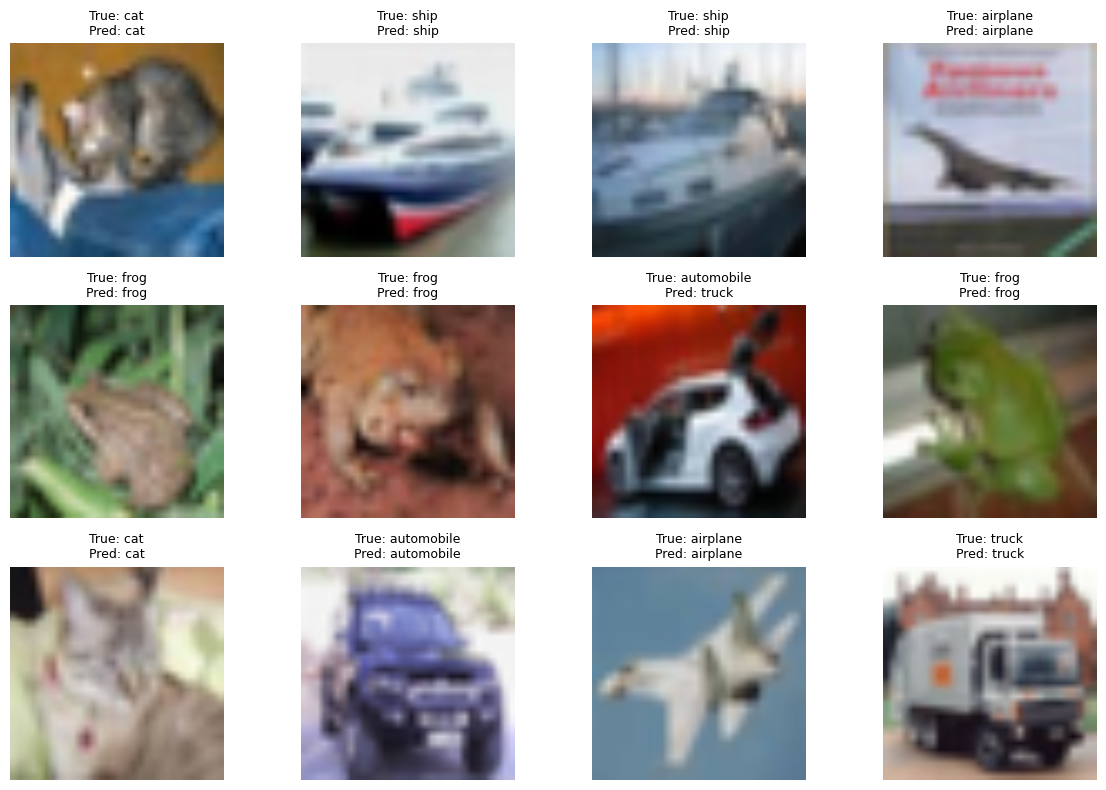

In [16]:
def show_predictions(model, data_loader, num_images=12):
    model.eval()
    images, labels = next(iter(data_loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 8))

    for i in range(num_images):
        plt.subplot(3, 4, i + 1)
        imshow(images[i])

        true_label = classes[labels[i]]
        pred_label = classes[preds[i].cpu()]

        title = f"True: {true_label}\nPred: {pred_label}"
        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


show_predictions(resnet18, test_loader)

## Explainable AI - interpretacja decyzji modelu metodą Grad-CAM

W celu rozszerzenia projektu o element wyjaśnialnej sztucznej inteligencji (XAI) zastosowano metodę Grad-CAM dla najlepszego modelu, czyli ResNet18.

Grad-CAM pozwala wskazać obszary obrazu, które miały największy wpływ na decyzję modelu. Metoda wykorzystuje gradienty przepływające przez ostatnią warstwę konwolucyjną sieci, aby utworzyć mapę aktywacji. Następnie mapa ta może zostać nałożona na oryginalny obraz jako heatmapa.

Dzięki temu można nie tylko sprawdzić, czy model poprawnie sklasyfikował obraz, ale również zobaczyć, na jakie fragmenty obrazu zwrócił największą uwagę.

In [27]:
for module in resnet18.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()
    module._backward_pre_hooks.clear()

print("Old hooks cleared")

Old hooks cleared


In [28]:
for param in resnet18.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)
resnet18.eval()

print("Gradients enabled for ResNet18")

Gradients enabled for ResNet18


In [29]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        input_tensor = input_tensor.clone().detach().to(device)
        input_tensor.requires_grad_(True)

        self.gradients = None
        self.activations = None

        self.model.zero_grad(set_to_none=True)

        with torch.enable_grad():
            output = self.model(input_tensor)

            if class_idx is None:
                class_idx = output.argmax(dim=1).item()

            score = output[:, class_idx]
            score.backward()

        if self.gradients is None:
            raise RuntimeError("Gradients are None. Grad-CAM did not collect gradients.")

        if self.activations is None:
            raise RuntimeError("Activations are None. Grad-CAM did not collect activations.")

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [31]:
def denormalize_image_tensor(img_tensor):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img


def show_gradcam_examples(model, data_loader, target_layer, num_images=2):
    model.eval()

    images, labels = next(iter(data_loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)

    gradcam = GradCAM(model, target_layer)

    try:
        plt.figure(figsize=(14, num_images * 3))

        for i in range(num_images):
            input_tensor = images_device[i].unsqueeze(0)

            cam, predicted_class = gradcam.generate(input_tensor)
            original_img = denormalize_image_tensor(images[i])

            plt.subplot(num_images, 2, 2 * i + 1)
            plt.imshow(original_img)
            plt.title(
                f"Obraz\nTrue: {classes[labels[i]]} | Pred: {classes[preds[i].cpu()]}"
            )
            plt.axis("off")

            plt.subplot(num_images, 2, 2 * i + 2)
            plt.imshow(original_img)
            plt.imshow(cam, cmap="jet", alpha=0.45)
            plt.title("Grad-CAM heatmap")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    finally:
        gradcam.remove_hooks()

In [32]:
def denormalize_image_tensor(img_tensor):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img


def show_gradcam_examples(model, data_loader, target_layer, num_images=4):
    model.eval()

    images, labels = next(iter(data_loader))
    images_device = images.to(device)

    with torch.no_grad():
        outputs = model(images_device)
        _, preds = torch.max(outputs, 1)

    gradcam = GradCAM(model, target_layer)

    plt.figure(figsize=(14, num_images * 3))

    for i in range(num_images):
        input_tensor = images_device[i].unsqueeze(0)

        cam, predicted_class = gradcam.generate(input_tensor)

        original_img = denormalize_image_tensor(images[i])

        plt.subplot(num_images, 2, 2 * i + 1)
        plt.imshow(original_img)
        plt.title(
            f"Obraz\nTrue: {classes[labels[i]]} | Pred: {classes[preds[i].cpu()]}"
        )
        plt.axis("off")

        plt.subplot(num_images, 2, 2 * i + 2)
        plt.imshow(original_img)
        plt.imshow(cam, cmap="jet", alpha=0.45)
        plt.title("Grad-CAM heatmap")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    gradcam.remove_hooks()

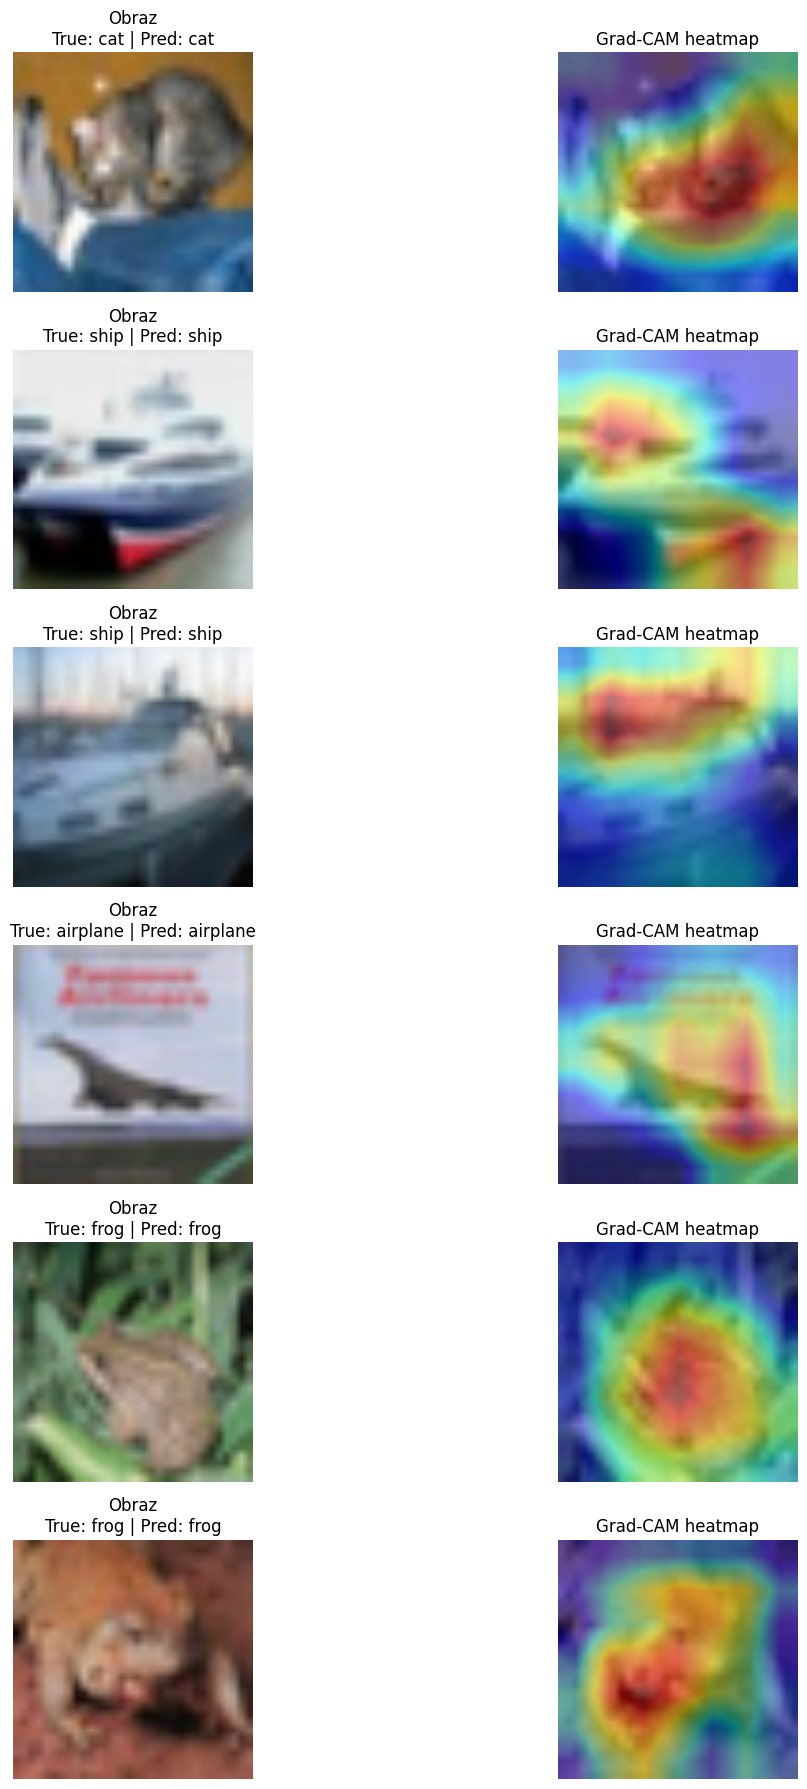

In [34]:
target_layer = resnet18.layer4[-1].conv2

show_gradcam_examples(
    model=resnet18,
    data_loader=test_loader,
    target_layer=target_layer,
    num_images=6
)

In [ ]:
## Interpretacja wyników Grad-CAM

Wygenerowane mapy Grad-CAM pokazują, które fragmenty obrazu miały największy wpływ na decyzję modelu ResNet18. Cieplejsze kolory oznaczają obszary o większym znaczeniu dla klasyfikacji.

W przedstawionych przykładach model często skupia się na obszarach odpowiadających głównemu obiektowi na obrazie, np. sylwetce kota lub fragmentom statku. Oznacza to, że decyzja modelu nie wynika wyłącznie z tła, ale z istotnych cech wizualnych obiektu.

Dodanie Grad-CAM rozszerza projekt o element Explainable AI, ponieważ pozwala lepiej zrozumieć, na podstawie jakich fragmentów obrazu model podejmuje decyzje.

## Grad-CAM dla błędnych predykcji

W tej części przeanalizowano przypadki, w których model ResNet18 popełnił błąd klasyfikacji. Dla takich przykładów wygenerowano mapy Grad-CAM wyjaśniające, które fragmenty obrazu najbardziej wpłynęły na błędną decyzję modelu.

Pozwala to sprawdzić, czy model skupił się na właściwym obiekcie, czy np. na tle, fragmencie obrazu albo cechach podobnych do innej klasy.

In [35]:
for module in resnet18.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()
    module._backward_pre_hooks.clear()

for param in resnet18.parameters():
    param.requires_grad = True

resnet18 = resnet18.to(device)
resnet18.eval()


def find_misclassified_examples(model, data_loader, max_images=4, max_batches=30):
    model.eval()
    examples = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(data_loader):
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            _, preds = torch.max(outputs, 1)

            wrong_indices = torch.where(preds.cpu() != labels)[0]

            for idx in wrong_indices:
                examples.append((
                    images[idx].clone(),
                    labels[idx].item(),
                    preds[idx].cpu().item()
                ))

                if len(examples) >= max_images:
                    return examples

            if batch_idx + 1 >= max_batches:
                break

    return examples


def show_misclassified_gradcam(model, data_loader, target_layer, num_images=4):
    examples = find_misclassified_examples(
        model=model,
        data_loader=data_loader,
        max_images=num_images
    )

    if len(examples) == 0:
        print("Nie znaleziono błędnych predykcji w sprawdzonym fragmencie zbioru.")
        return

    gradcam = GradCAM(model, target_layer)

    try:
        plt.figure(figsize=(14, len(examples) * 3))

        for i, (image, true_label, pred_label) in enumerate(examples):
            input_tensor = image.unsqueeze(0).to(device)

            cam, _ = gradcam.generate(input_tensor, class_idx=pred_label)

            original_img = denormalize_image_tensor(image)

            plt.subplot(len(examples), 2, 2 * i + 1)
            plt.imshow(original_img)
            plt.title(
                f"Błędna predykcja\nTrue: {classes[true_label]} | Pred: {classes[pred_label]}"
            )
            plt.axis("off")

            plt.subplot(len(examples), 2, 2 * i + 2)
            plt.imshow(original_img)
            plt.imshow(cam, cmap="jet", alpha=0.45)
            plt.title("Grad-CAM dla błędnej predykcji")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    finally:
        gradcam.remove_hooks()

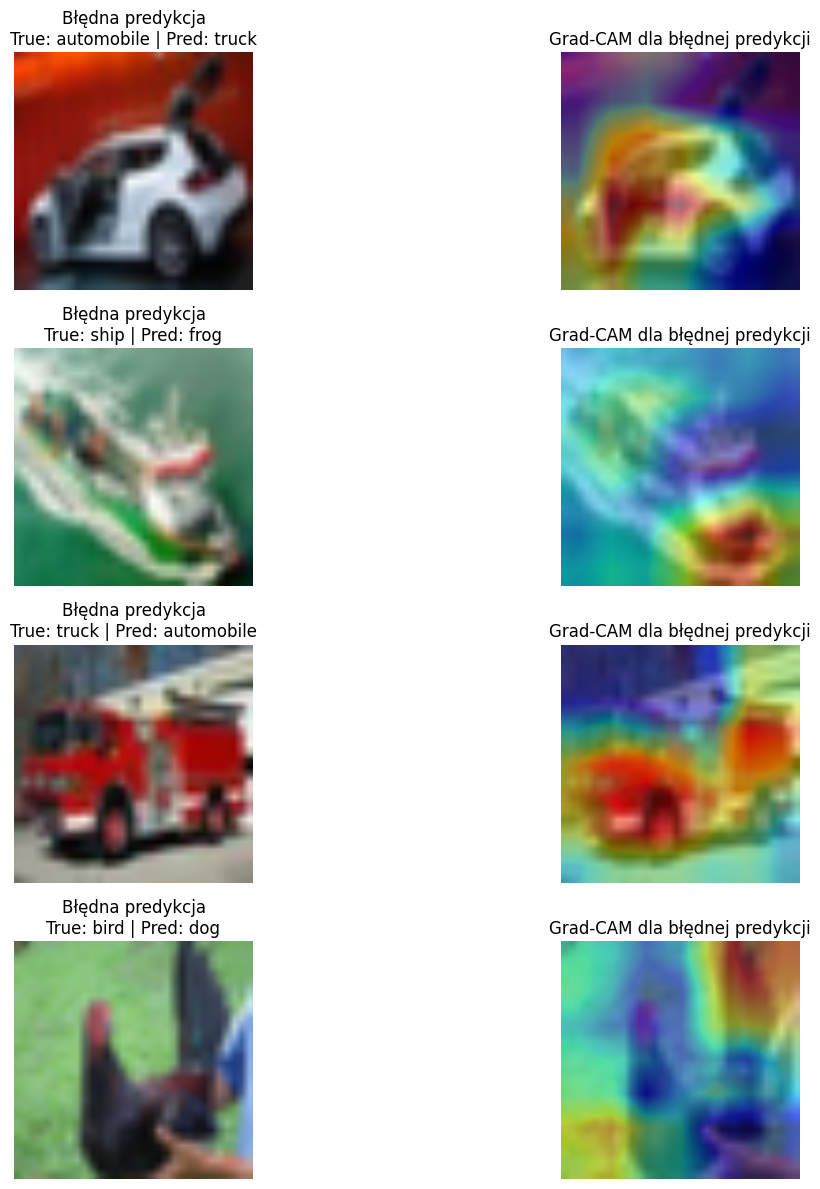

In [36]:
target_layer = resnet18.layer4[-1].conv2

show_misclassified_gradcam(
    model=resnet18,
    data_loader=test_loader,
    target_layer=target_layer,
    num_images=4
)

## Interpretacja Grad-CAM dla błędnych predykcji

Przedstawione przykłady pokazują przypadki, w których model ResNet18 popełnił błąd klasyfikacji. Mapy Grad-CAM pozwalają sprawdzić, które fragmenty obrazu miały największy wpływ na błędną decyzję modelu.

W części przypadków pomyłki są uzasadnione wizualnym podobieństwem klas, np. automobile/truck. W innych przypadkach aktywacje obejmują fragmenty tła lub niejednoznaczne obszary obrazu, co może sugerować, że model nie skupił się wyłącznie na właściwym obiekcie. Należy też uwzględnić ograniczenie zbioru CIFAR-10: obrazy mają bardzo niską rozdzielczość 32×32 piksele, przez co po przeskalowaniu są rozmazane, a mapy Grad-CAM mają charakter przybliżony.

## Wnioski końcowe

W projekcie porównano prostą sieć CNN trenowaną od zera z dwoma modelami pretrenowanymi: ResNet18 oraz MobileNetV2. Wyniki eksperymentu pokazują, że modele wykorzystujące transfer learning osiągnęły wyższą dokładność niż model bazowy, mimo że trenowano jedynie ich ostatnie warstwy klasyfikacyjne.

Najlepszy wynik uzyskał ResNet18, który osiągnął najwyższą dokładność oraz najkrótszy czas treningu. MobileNetV2 uzyskał nieco niższą dokładność, ale również pokazał przewagę transfer learningu nad prostą siecią CNN trenowaną od zera.

Projekt potwierdza, że dobór architektury sieci neuronowej ma duży wpływ na jakość klasyfikacji obrazów. Wykorzystanie modeli pretrenowanych pozwala uzyskać dobre wyniki nawet przy ograniczonym czasie treningu i stosunkowo niewielkim zbiorze danych.

Możliwym rozszerzeniem projektu byłoby przeprowadzenie treningu na pełnym zbiorze CIFAR-10, dodanie kolejnych architektur, takich jak EfficientNet-B0, oraz sprawdzenie odporności modeli na zakłócenia obrazów lub ataki adwersarialne.

Projekt rozszerzono również o element Explainable AI z wykorzystaniem metody Grad-CAM. Dzięki temu możliwa była wizualna interpretacja decyzji najlepszego modelu, czyli ResNet18. Grad-CAM pozwolił wskazać fragmenty obrazów, które miały największy wpływ na predykcję modelu, co zwiększa przejrzystość działania sieci neuronowej.